In [40]:
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import re
import emoji
import os

In [41]:
DIR_DATA = "../data"
DIR_RAW_DATA = DIR_DATA + "/raw"
DIR_CLEANED_DATA = DIR_DATA + "/cleaned"

df_product = pd.read_csv(DIR_RAW_DATA + "/products.csv")
df_shop = pd.read_csv(DIR_RAW_DATA + "/shops.csv")

# Data Profiling

In [42]:
print("=" * 60)
print("PRODUCTS DATASET")
print("=" * 60)

print(f"Shape: {df_product.shape[0]:,} rows × {df_product.shape[1]} column\n")

print("Data types:")
print(df_product.dtypes)

print("First 5 rows")
display(df_product.head())

print("Last 5 rows:")
display(df_product.tail())

print("Numeric summary:")
display(df_product.describe())

print("Categorical summary")
display(df_product.describe(include=["object", "bool"]))

PRODUCTS DATASET
Shape: 17,458 rows × 14 column

Data types:
product_id               int64
shop_id                  int64
shop_location           object
product_name            object
category                object
sub_category            object
original_price         float64
current_price          float64
discount_percentage      int64
historical_sold          int64
rating_average         float64
is_sold_out               bool
liked_count              int64
crawled_at              object
dtype: object
First 5 rows


,product_id,shop_id,shop_location,product_name,category,sub_category,original_price,current_price,discount_percentage,historical_sold,rating_average,is_sold_out,liked_count,crawled_at
0,20478055681,962733632,NaN,Nơ cài cổ áo màu đen thời trang lịch lãm cho nam,Thời trang Nam,Cà vạt & Nơ cổ,38232.0,38232.0,0,6000,4.876190,False,134,2026-03-07T21:13:12.024429
1,16494811244,1008809970,Nước ngoài,Cà Vạt Nam Bản Nhỏ 8cm Có Khóa Kéo Màu Đỏ Đen ...,Thời trang Nam,Cà vạt & Nơ cổ,54000.0,53000.0,2,10000,4.828411,False,413,2026-03-07T21:13:12.024447
2,21922796676,322530470,Nước ngoài,Cà vạt EFAN vải lụa dệt jacquard nhiều màu tùy...,Thời trang Nam,Cà vạt & Nơ cổ,59399.0,59399.0,0,3000,4.950570,False,391,2026-03-07T21:13:12.024454
3,28227765200,183199642,Hà Tĩnh,Cà vạt thắt sẵn bản 8cm dành cho người bận rộn...,Thời trang Nam,Cà vạt & Nơ cổ,59000.0,38940.0,34,652,4.764045,False,6,2026-03-07T21:13:12.024461
4,17898918694,308456542,NaN,Cà Vạt Nơ Màu Đen Thời Trang Công Sở Cho Nam vn,Thời trang Nam,Cà vạt & Nơ cổ,45700.0,45700.0,0,379,4.850000,False,16,2026-03-07T21:13:12.024467


Last 5 rows:


,product_id,shop_id,shop_location,product_name,category,sub_category,original_price,current_price,discount_percentage,historical_sold,rating_average,is_sold_out,liked_count,crawled_at
17453,3257604188,271159454,NaN,[Big size 90kg] Quần dài tập gym yoga nữ vải d...,Thời trang Nữ,Đồ tập,199000.0,99500.0,50,10000,4.929809,False,2745,2026-03-07T21:39:48.243413
17454,5606443239,4365245,TP. Hồ Chí Minh,Đồ bơi nữ kín đáo tay ngắn CÓ MÚT CÓ SIZE-Biki...,Thời trang Nữ,Đồ tập,100000.0,100000.0,0,10000,4.931053,False,6816,2026-03-07T21:39:48.243417
17455,55250862101,255704819,NaN,[Hàng tặng không bán] - Quà tặng ngẫu nhiên (á...,Thời trang Nữ,Đồ tập,300000.0,290000.0,3,10000,4.901189,False,70,2026-03-07T21:39:48.243421
17456,2911577608,39553085,Bình Dương,Áo tập gym yoga nữ chất dệt kim siêu đẹp ami,Thời trang Nữ,Đồ tập,180000.0,180000.0,0,10000,4.928020,False,2337,2026-03-07T21:39:48.243426
17457,8642527008,217580171,NaN,Quần dài thể thao ANRAN cạp cao thích hợp cho ...,Thời trang Nữ,Đồ tập,252000.0,217000.0,14,10000,4.918089,False,3243,2026-03-07T21:39:48.243430


Numeric summary:


,product_id,shop_id,original_price,current_price,discount_percentage,historical_sold,rating_average,liked_count
count,1.745800e+04,1.745800e+04,1.745800e+04,1.745800e+04,17458.000000,1.745800e+04,17458.000000,17458.000000
mean,1.941969e+10,4.342179e+08,2.120194e+05,1.556101e+05,24.156318,1.824617e+04,4.825473,3353.549891
std,9.547888e+09,3.953454e+08,2.766114e+05,2.302663e+05,19.867834,5.689014e+04,0.207258,7130.099685
min,1.412997e+07,2.963800e+04,1.080000e+03,1.000000e+03,0.000000,0.000000e+00,0.000000,0.000000
25%,1.201424e+10,8.091946e+07,6.900000e+04,5.000000e+04,0.000000,1.000000e+03,4.787634,78.000000
50%,2.186000e+10,3.074680e+08,1.570000e+05,1.094900e+05,25.000000,8.000000e+03,4.866667,558.000000
75%,2.567321e+10,7.183728e+08,2.700000e+05,1.860300e+05,41.000000,2.000000e+04,4.918159,3331.750000
max,5.815632e+10,1.686490e+09,8.367000e+06,6.900000e+06,99.000000,4.000000e+06,5.000000,156920.000000


Categorical summary


,shop_location,product_name,category,sub_category,is_sold_out,crawled_at
count,10978,17458,17458,17458,17458,17458
unique,58,17204,2,40,1,17458
top,Hà Nội,Áo Khoác Nỉ Bông In Nổi Boxy THREE STARS Unise...,Thời trang Nam,Khác,False,2026-03-07T21:39:48.243430
freq,5017,6,9231,837,17458,1


In [43]:
print("=" * 60)
print("SHOPS DATASET")
print("=" * 60)

print(f"Shape: {df_shop.shape[0]:,} rows × {df_shop.shape[1]} column\n")

print("Data types:")
print(df_shop.dtypes)

print("First 5 rows")
display(df_shop.head())

print("Last 5 rows:")
display(df_shop.tail())

print("Numeric summary:")
display(df_shop.describe())

print("Categorical summary")
display(df_shop.describe(include=["object", "bool"]))

SHOPS DATASET
Shape: 5,638 rows × 10 column

Data types:
shop_id               int64
shop_name            object
location             object
rating_star         float64
follower_count        int64
is_official_shop       bool
item_count            int64
response_rate         int64
response_time         int64
crawled_at           object
dtype: object
First 5 rows


,shop_id,shop_name,location,rating_star,follower_count,is_official_shop,item_count,response_rate,response_time,crawled_at
0,962733632,Sthgruybfub.vn,NaN,4.784238,33775,False,9879,100,799,2026-03-07T21:51:00.837947
1,1008809970,Cà vạt chuyên dụng yzq007.vn,Nước ngoài,4.833333,1879,False,96,100,6497,2026-03-07T21:51:13.492509
2,322530470,ewann.vn,Nước ngoài,4.904741,11968,True,4429,97,6513,2026-03-07T21:51:26.016777
3,183199642,Binstore thời trang nam,Hà Tĩnh,4.829123,12683,False,142,91,2361,2026-03-07T21:51:38.013949
4,308456542,cheesenhujm.vn,NaN,4.666000,14692,False,3412,100,767,2026-03-07T21:51:50.661447


Last 5 rows:


,shop_id,shop_name,location,rating_star,follower_count,is_official_shop,item_count,response_rate,response_time,crawled_at
5633,1157529323,LuvGift - Shop Quà Lưu Niệm,TP. Hồ Chí Minh,4.863184,348,False,838,81,6899,2026-03-10T23:56:00.077985
5634,339701020,Anime_icos.vn,Nước ngoài,4.859583,1491,False,51,0,0,2026-03-10T23:56:17.078278
5635,114926991,Sugar DIY,Hà Nội,4.680965,3317,False,463,50,3607,2026-03-10T23:56:35.417239
5636,263073233,XƯỞNG IN SỈ LẺ,NaN,4.148285,26822,False,1918,55,11368,2026-03-10T23:56:49.748003
5637,55970873,Number Plus Center,TP. Hồ Chí Minh,4.883764,1794,False,97,97,6104,2026-03-10T23:57:50.515681


Numeric summary:


,shop_id,rating_star,follower_count,item_count,response_rate,response_time
count,5.638000e+03,5638.000000,5.638000e+03,5638.000000,5638.000000,5638.000000
mean,4.857098e+08,4.814058,6.282036e+04,555.609436,78.521816,7359.534941
std,4.275241e+08,0.145497,1.738772e+05,6859.558985,28.450782,5704.448327
min,2.963800e+04,0.000000,1.000000e+00,0.000000,0.000000,0.000000
25%,1.007013e+08,4.773026,3.242500e+03,43.000000,70.250000,3438.250000
50%,3.581381e+08,4.846461,1.471400e+04,110.000000,91.000000,6738.500000
75%,8.148517e+08,4.893543,5.575225e+04,295.000000,99.000000,10388.500000
max,1.686490e+09,5.000000,5.457422e+06,421653.000000,100.000000,80412.000000


Categorical summary


,shop_name,location,is_official_shop,crawled_at
count,5638,3970,5638,5638
unique,5638,58,2,5638
top,Number Plus Center,Hà Nội,False,2026-03-10T23:57:50.515681
freq,1,1671,5191,1


# Missing Values

In [44]:
print("=" * 60)
print("PRODUCTS DATASET")
print("=" * 60)

missing_product = df_product.isnull().sum()
missing_product = missing_product[missing_product > 0].sort_values(ascending=False)

if missing_product.empty:
    print("No missing values")
else:
    df_missing_product = pd.DataFrame({
        "Column": missing_product.index,
        "Missing Count": missing_product.values,
        "Percentage": (missing_product.values / len(df_product) * 100).round(2)
    }).reset_index(drop=True)
    display(df_missing_product)

PRODUCTS DATASET


,Column,Missing Count,Percentage
0,shop_location,6480,37.12


In [45]:
print("=" * 60)
print("SHOPS DATASET")
print("=" * 60)

missing_shop = df_shop.isnull().sum()
missing_shop = missing_shop[missing_shop > 0].sort_values(ascending=False)

if missing_shop.empty:
    print("No missing values")
else:
    df_missing_shop = pd.DataFrame({
        "Column": missing_shop.index,
        "Missing Count": missing_shop.values,
        "Percentage": (missing_shop.values / len(df_shop) * 100).round(2)
    }).reset_index(drop=True)
    display(df_missing_shop)

SHOPS DATASET


,Column,Missing Count,Percentage
0,location,1668,29.58


- **Dataset product:** The product information doesn't include "shop_location", so we will drop this column.
- **Dataset shop:** Due to the high rate of missing values in the "location" column, we will fill them with "Không xác định".

In [46]:
df_product.drop(columns=["shop_location"], inplace=True)

df_shop["location"] = df_shop["location"].fillna("Không xác định")

print("=" * 60)
print("CHECK MISSING DATA AGAIN")
print("=" * 60)

missing_product = df_product.isnull().sum()
missing_product = missing_product[missing_product > 0].sort_values(ascending=False)

missing_shop = df_shop.isnull().sum()
missing_shop = missing_shop[missing_shop > 0].sort_values(ascending=False)

if missing_product.empty:
    print("No missing values found in product data")
else:
    print("Product data still contains missing values")

if missing_shop.empty:
    print("No missing values found in shop data")
else:
    print("Shop data still contains missing values")

CHECK MISSING DATA AGAIN
No missing values found in product data
No missing values found in shop data


# Duplicates & Junk

In [47]:
print(f"Duplicate rows in product data: {df_product.duplicated().sum():,}")
print(f"Duplicate rows in shop data: {df_shop.duplicated().sum():,}")

Duplicate rows in product data: 0
Duplicate rows in shop data: 0


# Data Formatting

## Product dataset

### Check data types

In [48]:
print("Data types:")
display(df_product.dtypes)

Data types:


product_id               int64
shop_id                  int64
product_name            object
category                object
sub_category            object
original_price         float64
current_price          float64
discount_percentage      int64
historical_sold          int64
rating_average         float64
is_sold_out               bool
liked_count              int64
crawled_at              object
dtype: object

In [49]:
print("Converting 'crawled_at' data type from object to datetime...")
df_product["crawled_at"] = pd.to_datetime(df_product["crawled_at"])
print("Current data type of 'crawled_at' column:", df_product["crawled_at"].dtype)

print("\nConverting 'original_price' and 'current_price' data types from float64 to int64...")
df_product["original_price"] = df_product["original_price"].astype(int)
df_product["current_price"] = df_product["current_price"].astype(int)
print("Current data type of 'original_price' column:", df_product["original_price"].dtype)
print("Current data type of 'current_price' column:", df_product["current_price"].dtype)

Converting 'crawled_at' data type from object to datetime...
Current data type of 'crawled_at' column: datetime64[ns]

Converting 'original_price' and 'current_price' data types from float64 to int64...
Current data type of 'original_price' column: int64
Current data type of 'current_price' column: int64


### Check whitespace and emoji in product_name columns

In [50]:
# Check whitespace in text columns
product_ws = (df_product["product_name"].str.strip() != df_product["product_name"]).sum()
print(f"product_name with leading/trailing whitespace: {product_ws}")

product_name with leading/trailing whitespace: 16


In [51]:
# Strip whitespace
df_product["product_name"] = df_product["product_name"].str.strip()
# Verify
product_ws_after = (df_product["product_name"].str.strip() != df_product["product_name"]).sum()
print(f"After fix – product_name whitespace issues: {product_ws_after}")

After fix – product_name whitespace issues: 0


In [52]:
# Remove emojis/icons from product_name
def remove_emoji(text):
    return emoji.replace_emoji(text, replace="")

In [53]:
# Check how many product names contain emojis BEFORE cleaning
has_emoji_before = df_product["product_name"].apply(lambda x: x != remove_emoji(x)).sum()
print(f"Product names containing emojis: {has_emoji_before}")
# Show some examples
if has_emoji_before > 0:
    mask = df_product["product_name"].apply(lambda x: x != remove_emoji(x))
    print("\nExamples:")
    for name in df_product.loc[mask, "product_name"].head(5):
        print(f"  Before: {name}")
        print(f"  After:  {remove_emoji(name)}")
        print()

# Apply cleaning
df_product["product_name"] = df_product["product_name"].apply(remove_emoji)

# Also strip again in case removing emoji left extra spaces
df_product["product_name"] = df_product["product_name"].str.strip()

# Verify
has_emoji_after = df_product["product_name"].apply(lambda x: x != remove_emoji(x)).sum()
print(f"Product names with emojis after cleaning: {has_emoji_after}")


Product names containing emojis: 391

Examples:
  Before: Nơ chú rể 🤵‍♂️  2024 nhọn hai đầu thời trang phụ kiện nam năm mới Giangpkc
  After:  Nơ chú rể   2024 nhọn hai đầu thời trang phụ kiện nam năm mới Giangpkc

  Before: Áo Mixi Gaming 🎁 FREESHIP 🎁 Giảm Ngay 10K Khi Nhâp [ MIXI ] - Bộ Quần Áo Mixi Gaming Giá Rẻ Có Đủ Size
  After:  Áo Mixi Gaming  FREESHIP  Giảm Ngay 10K Khi Nhâp [ MIXI ] - Bộ Quần Áo Mixi Gaming Giá Rẻ Có Đủ Size

  Before: siêu lụa dập ly 2 cm  50 k /1 m  khổ 1 m5⭐️⭐️
  After:  siêu lụa dập ly 2 cm  50 k /1 m  khổ 1 m5

  Before: DEAL GIÁ SỐC🔥Áo Thun nam / áo sơ mi nam tay ngắn / Quần Jeans Form Rộng Thời Trang Cho Nam
  After:  DEAL GIÁ SỐCÁo Thun nam / áo sơ mi nam tay ngắn / Quần Jeans Form Rộng Thời Trang Cho Nam

  Before: Áo Ngôi Sao Khúc Côn Cầu Phon Chay ⭐️
  After:  Áo Ngôi Sao Khúc Côn Cầu Phon Chay 

Product names with emojis after cleaning: 0


### Check category consistency

In [54]:
print("Product categories:")
print(df_product["category"].value_counts().to_string())
print(f"\nProduct sub_categories ({df_product['sub_category'].nunique()} unique):")
print(df_product["sub_category"].value_counts().to_string())

Product categories:
category
Thời trang Nam    9231
Thời trang Nữ     8227

Product sub_categories (40 unique):
sub_category
Khác                          837
Áo                            814
Cà vạt & Nơ cổ                492
Vải                           467
Trang Phục Ngành Nghề         466
Đồ Ngủ                        458
Phụ Kiện Nam                  458
Trang Sức Nam                 457
Trang Phục Truyền Thống       455
Thắt Lưng Nam                 450
Đồ Hóa Trang                  448
Kính Mắt Nam                  448
Đồ Lót                        447
Quần Jeans                    446
Áo Ba Lỗ                      444
Quần Dài/Quần Âu              444
Quần Short                    441
Đồ Bầu                        433
Đồ tập                        433
Vớ Tất                        431
Chân váy                      430
Váy cưới                      429
Quần                          428
Vớ/ Tất                       426
Đồ ngủ                        425
Áo Khoác                 

In [55]:
# Group sub_categories
sub_category_mapping = {
    # Áo
    "Áo": "Áo",
    "Áo Ba Lỗ": "Áo",

    # Quần dài & Jeans
    "Quần Dài/Quần Âu": "Quần dài & Jeans",
    "Quần Jeans": "Quần dài & Jeans",
    "Quần": "Quần dài & Jeans",
    "Quần jeans": "Quần dài & Jeans",
    
    # Quần đùi
    "Quần Short": "Quần đùi",
    "Quần đùi": "Quần đùi",

    # Đồ đông/Nỉ
    "Áo Hoddie, Áo Len & Áo Nỉ": "Đồ đông/Nỉ",
    "Hoodie và Áo nỉ": "Đồ đông/Nỉ",
    "Áo len & Cardigan": "Đồ đông/Nỉ",

    # Áo khoác & Vest
    "Áo Khoác": "Áo khoác & Vest",
    "Áo Vest và Blazer": "Áo khoác & Vest",
    "Áo khoác, Áo choàng & Vest": "Áo khoác & Vest",

    # Đồ mặc nhà
    "Đồ Ngủ": "Đồ mặc nhà",
    "Đồ Bộ": "Đồ mặc nhà",
    "Bộ": "Đồ mặc nhà",
    "Đồ ngủ": "Đồ mặc nhà",

    # Đồ lót
    "Đồ Lót": "Đồ lót",
    "Đồ lót": "Đồ lót",

    # Tất/Vớ
    "Vớ Tất": "Tất/Vớ",
    "Vớ/ Tất": "Tất/Vớ",

    # Trang phục truyền thống
    "Trang Phục Truyền Thống": "Trang phục truyền thống",
    "Đồ truyền thống": "Trang phục truyền thống",

    # Đồ hóa trang
    "Đồ Hóa Trang": "Đồ hóa trang",
    "Đồ hóa trang": "Đồ hóa trang",

    # Khác
    "Khác": "Khác",

    # Nhóm riêng Nam – Phụ kiện thời trang
    "Cà vạt & Nơ cổ": "Phụ kiện thời trang",
    "Kính Mắt Nam": "Phụ kiện thời trang",
    "Thắt Lưng Nam": "Phụ kiện thời trang",
    "Phụ Kiện Nam": "Phụ kiện thời trang",
    "Trang Sức Nam": "Phụ kiện thời trang",

    # Nhóm riêng Nam
    "Trang Phục Ngành Nghề": "Trang phục ngành nghề",

    # Nhóm riêng Nữ
    "Vải": "Vải",
    "Chân váy": "Chân váy",
    "Váy cưới": "Váy cưới",
    "Đầm/Váy": "Đầm/Váy",
    "Đồ Bầu": "Đồ bầu",
    "Đồ liền thân": "Đồ liền thân",
    "Đồ tập": "Đồ tập",
}

df_product["sub_category"] = df_product["sub_category"].map(sub_category_mapping)

print("After group: ")
print("Product categories:")
print(df_product["category"].value_counts().to_string())
print(f"\nProduct sub_categories ({df_product['sub_category'].nunique()} unique):")
print(df_product["sub_category"].value_counts().to_string())


After group: 
Product categories:
category
Thời trang Nam    9231
Thời trang Nữ     8227

Product sub_categories (20 unique):
sub_category
Phụ kiện thời trang        2305
Quần dài & Jeans           1669
Đồ mặc nhà                 1471
Áo                         1258
Áo khoác & Vest            1234
Đồ đông/Nỉ                 1143
Tất/Vớ                      857
Đồ lót                      850
Khác                        837
Quần đùi                    825
Trang phục truyền thống     819
Đồ hóa trang                806
Vải                         467
Trang phục ngành nghề       466
Đồ tập                      433
Đồ bầu                      433
Chân váy                    430
Váy cưới                    429
Đầm/Váy                     378
Đồ liền thân                348


## Shop dataset

### Check id_shop

In [56]:
# Cross-Validation Shop ID

shop_ids_in_shops = set(df_shop["shop_id"].unique())
shop_ids_in_products = set(df_product["shop_id"].unique())

# 1. Are there any shops in the Products table that DO NOT EXIST in the Shops table?
missing_in_shops = shop_ids_in_products - shop_ids_in_shops
print(f"Number of Shop IDs present in Products but MISSING in Shops: {len(missing_in_shops)}")
if len(missing_in_shops) > 0:
    print(f"   There are {len(missing_in_shops)} shops with missing information. The Shop IDs are:")
    print(f"   {list(missing_in_shops)[:5]}", "..." if len(missing_in_shops) > 5 else "")
else:
    print("   All products have corresponding shop information.")

# 2. Are there any shops in the Shops table that HAVE NO Products?
missing_in_products = shop_ids_in_shops - shop_ids_in_products
print(f"\nNumber of Shop IDs present in Shops but HAVE NO products in Products: {len(missing_in_products)}")
if len(missing_in_products) > 0:
    print(f"   There are {len(missing_in_products)} empty shops (no products sold).")
else:
    print("   Every collected shop has at least 1 product.")


Number of Shop IDs present in Products but MISSING in Shops: 0
   All products have corresponding shop information.

Number of Shop IDs present in Shops but HAVE NO products in Products: 0
   Every collected shop has at least 1 product.


### Check data types

In [57]:
print("Data types:")
display(df_shop.dtypes)

Data types:


shop_id               int64
shop_name            object
location             object
rating_star         float64
follower_count        int64
is_official_shop       bool
item_count            int64
response_rate         int64
response_time         int64
crawled_at           object
dtype: object

In [58]:
print("Converting 'crawled_at' data type from object to datetime...")
df_shop["crawled_at"] = pd.to_datetime(df_shop["crawled_at"])
print("Current data type of 'crawled_at' column:", df_shop["crawled_at"].dtype)

Converting 'crawled_at' data type from object to datetime...
Current data type of 'crawled_at' column: datetime64[ns]


### Check whitespace and emojis/icon in shop_name columns

In [59]:
# Check whitespace in text columns
shop_ws = (df_shop["shop_name"].str.strip() != df_shop["shop_name"]).sum()
print(f"shop_name with leading/trailing whitespace: {shop_ws}")

shop_name with leading/trailing whitespace: 142


In [60]:
# Strip whitespace
df_shop["shop_name"] = df_shop["shop_name"].str.strip()
# Verify
shop_ws_after = (df_shop["shop_name"].str.strip() != df_shop["shop_name"]).sum()
print(f"After fix – shop_name whitespace issues: {shop_ws_after}")

After fix – shop_name whitespace issues: 0


In [61]:
# Check how many shop names contain emojis BEFORE cleaning
has_emoji_before = df_shop["shop_name"].apply(lambda x: x != remove_emoji(x)).sum()
print(f"Shop names containing emojis: {has_emoji_before}")
# Show some examples
if has_emoji_before > 0:
    mask = df_shop["shop_name"].apply(lambda x: x != remove_emoji(x))
    print("\nExamples:")
    for name in df_shop.loc[mask, "shop_name"].head(5):
        print(f"  Before: {name}")
        print(f"  After:  {remove_emoji(name)}")
        print()

# Apply cleaning
df_shop["shop_name"] = df_shop["shop_name"].apply(remove_emoji)

# Also strip again in case removing emoji left extra spaces
df_shop["shop_name"] = df_shop["shop_name"].str.strip()

# Verify
has_emoji_after = df_shop["shop_name"].apply(lambda x: x != remove_emoji(x)).sum()
print(f"Shop names with emojis after cleaning: {has_emoji_after}")


Shop names containing emojis: 25

Examples:
  Before: NHYGSV ❄️ Hàng đan mát mẻ ❄️
  After:  NHYGSV  Hàng đan mát mẻ 

  Before: Nắng Sport⚽️
  After:  Nắng Sport

  Before: 🌸TỔNG KHO BUÔN🌸
  After:  TỔNG KHO BUÔN

  Before: DUDU CAP🧢
  After:  DUDU CAP

  Before: PINK RIBBON SHOP 🎀
  After:  PINK RIBBON SHOP 

Shop names with emojis after cleaning: 0


### Check location consistency (typos, duplicates) and whitespace in location columns

In [62]:
print("Unique locations in shops:")
print(df_shop["location"].unique().tolist())

Unique locations in shops:
['Không xác định', 'Nước ngoài', 'Hà Tĩnh', 'Hà Nội', 'TP. Hồ Chí Minh', 'Thái Nguyên', 'Hưng Yên', 'Hải Phòng', 'Đồng Nai', 'Quảng Ninh', 'Hải Dương', 'Bình Dương', 'Khánh Hòa', 'Bình Thuận', 'Gia Lai', 'Bắc Ninh', 'Bình Định', 'Nam Định', 'Đà Nẵng', 'Thái Bình', 'Thanh Hóa', 'Lào Cai', 'Thừa Thiên Huế', 'Hàn Quốc', 'Bắc Giang', 'Hòa Bình', 'Lạng Sơn', 'Bạc Liêu', 'Hà Nam', 'Sóc Trăng', 'Cần Thơ', 'Đắk Lắk', 'Quảng Nam', 'Hậu Giang', 'Đồng Tháp', 'Cao Bằng', 'Yên Bái', 'Long An', 'Phú Thọ', 'Bà Rịa - Vũng Tàu', 'Ninh Thuận', 'Vĩnh Phúc', 'Ninh Bình', 'Quảng Bình', 'Tiền Giang', 'Nghệ An', 'Tây Ninh', 'An Giang', 'Kon Tum', 'Trà Vinh', 'Vĩnh Long', 'Lâm Đồng', 'Kiên Giang', 'Cà Mau', 'Phú Yên', 'Quảng Ngãi', 'Bến Tre', 'Sơn La', 'Đắk Nông']


# Outliers

In [63]:
# Identify numeric columns worth checking for outliers
product_numeric_cols = ["original_price", "current_price", "discount_percentage", "historical_sold", "rating_average", "liked_count"]

shop_numeric_cols = ["rating_star", "follower_count", "item_count", "response_rate", "response_time"]


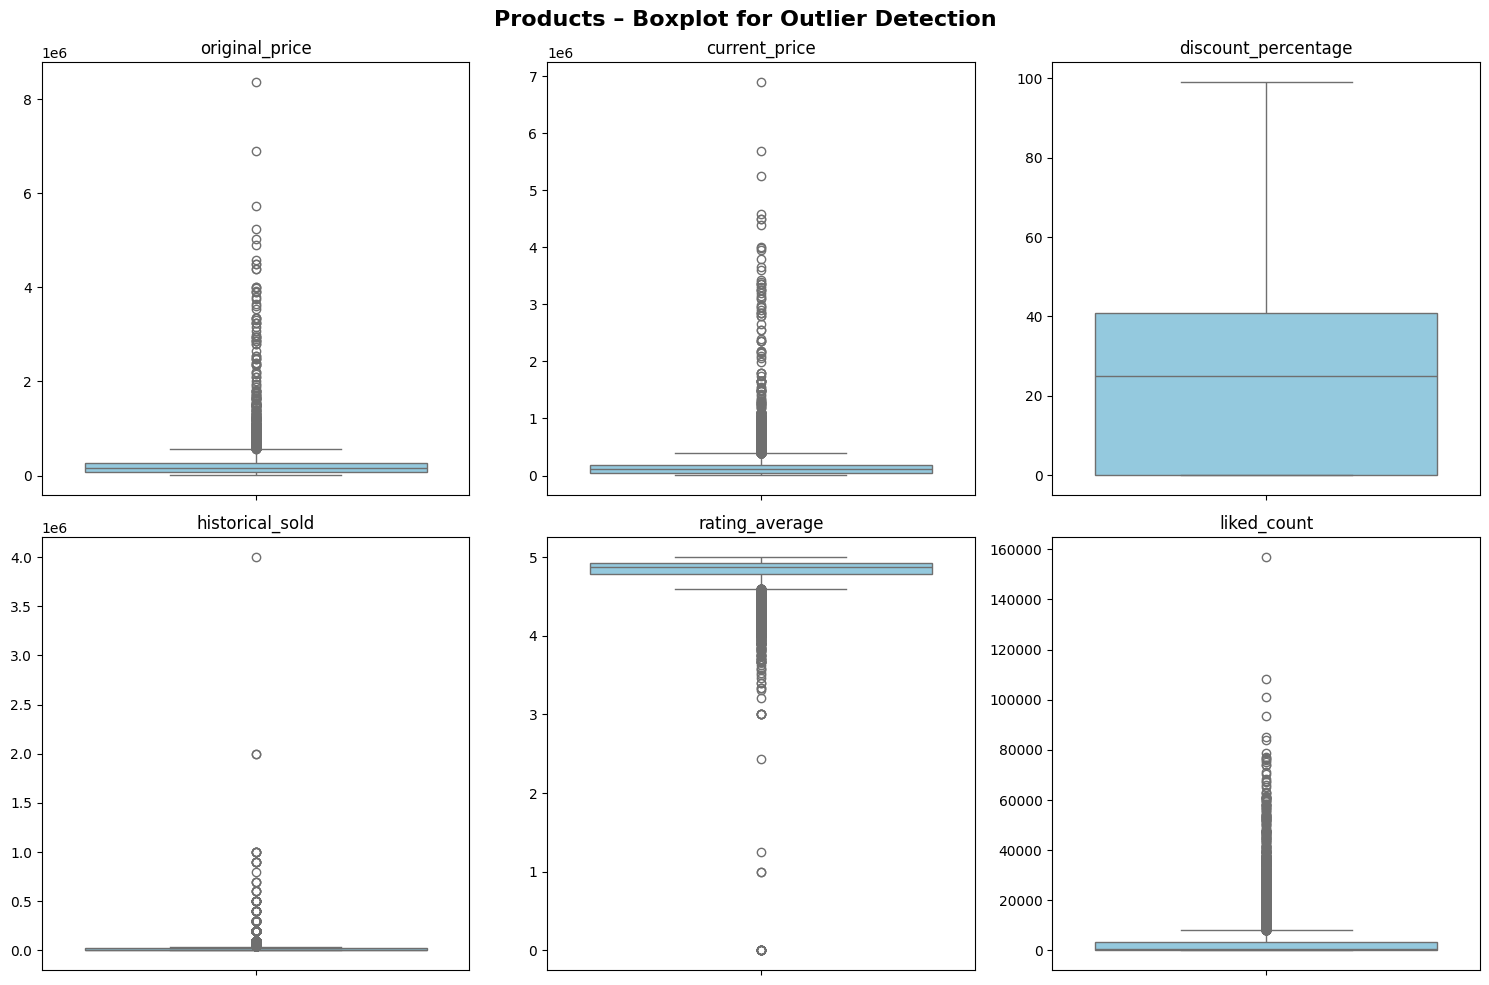

In [64]:
# Boxplot visualization for Products
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Products – Boxplot for Outlier Detection", fontsize=16, fontweight="bold")

for i, col in enumerate(product_numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df_product, y=col, ax=ax, color="skyblue")
    ax.set_title(col)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

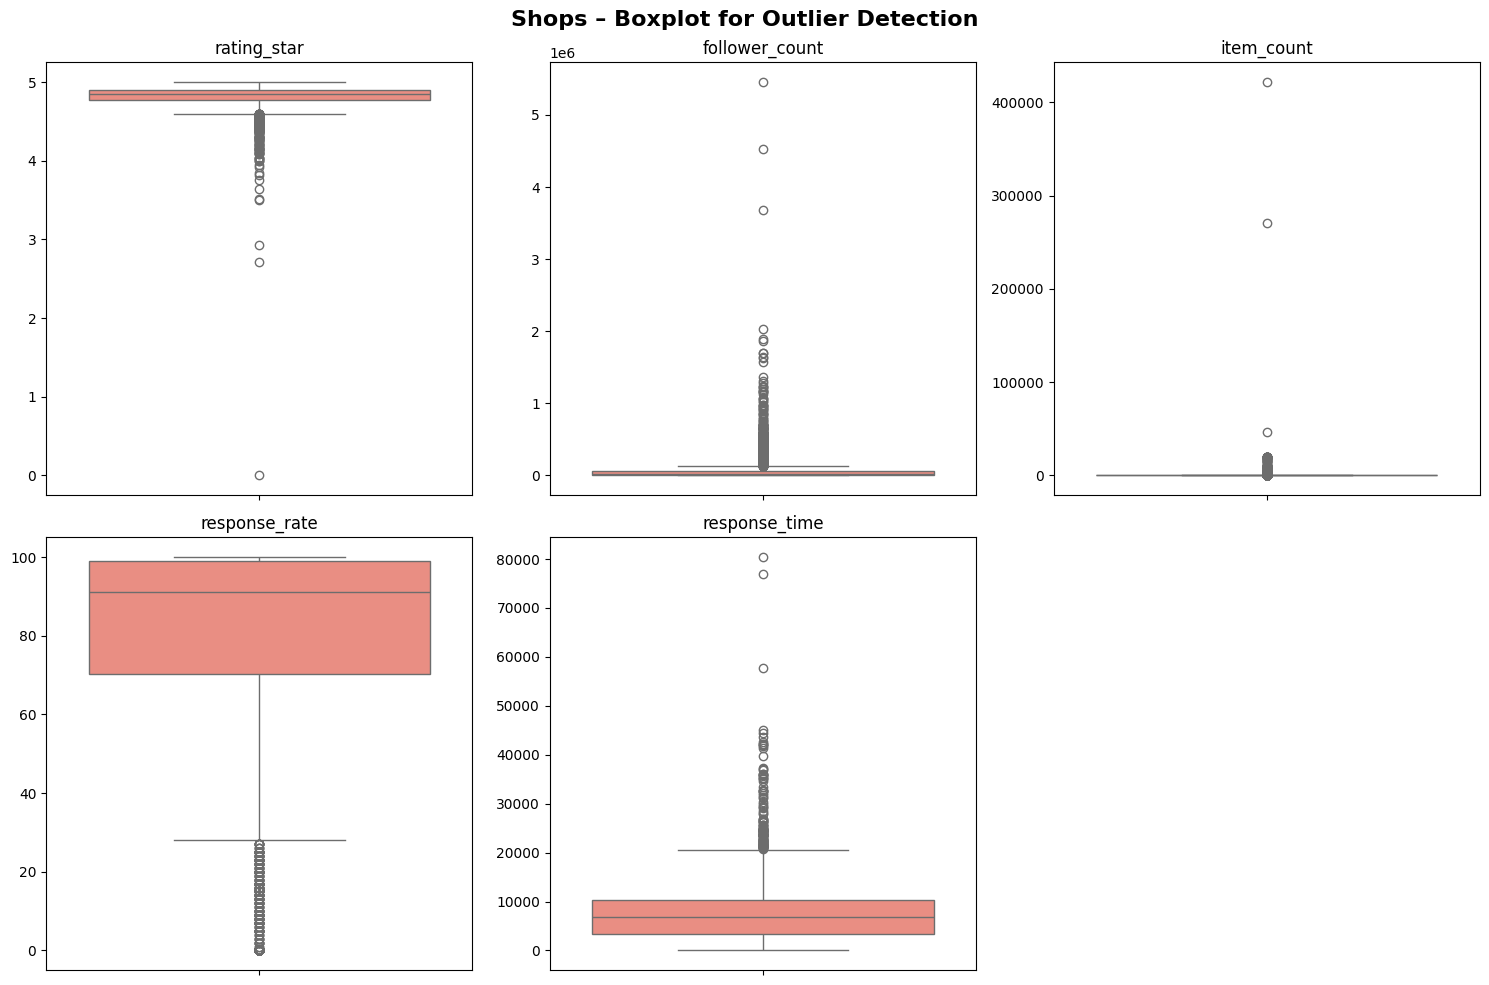

In [65]:
# Boxplot visualization for Shops
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # ← thêm dòng này
fig.suptitle("Shops – Boxplot for Outlier Detection", fontsize=16, fontweight="bold")

for i, col in enumerate(shop_numeric_cols):
    sns.boxplot(data=df_shop, y=col, ax=axes[i], color="salmon")
    axes[i].set_title(col)
    axes[i].set_ylabel("")

for j in range(len(shop_numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [66]:
# Calculate IQR bounds for a given column
def calc_iqr_bounds(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, df[col].min())
    upper_bound = min(Q3 + 1.5 * IQR, df[col].max())
    return Q1, Q3, IQR, lower_bound, upper_bound

# Count outliers using the IQR (Interquartile Range) method
def count_outliers_iqr(df, columns):
    results = []
    for col in columns:
        Q1, Q3, IQR, lower_bound, upper_bound = calc_iqr_bounds(df, col)

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        results.append({
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": len(outliers),
            "Outlier %": round(len(outliers) / len(df) * 100, 2)
        })
    return pd.DataFrame(results)

# For each numeric column, show outliers below lower bound and above upper bound
def inspect_outliers(df, columns, display_cols, dataset_name="Dataset"):
    """."""
    for col in columns:
        Q1, Q3, IQR, lower_bound, upper_bound = calc_iqr_bounds(df, col)
        below = df[df[col] < lower_bound]
        above = df[df[col] > upper_bound]

        print("=" * 60)
        print(f"{dataset_name} – Column: {col}")
        print(f"   Q1={Q1:,.2f}  |  Q3={Q3:,.2f}  |  IQR={IQR:,.2f}")
        print(f"   Lower Bound={lower_bound:,.2f}  |  Upper Bound={upper_bound:,.2f}")
        print("-" * 60)

        # Below lower bound
        print(f"   Below lower bound: {len(below)} rows")
        if len(below) > 0:
            display(below[display_cols + [col]].head(10))

        # Above upper bound
        print(f"   Above upper bound: {len(above)} rows")
        if len(above) > 0:
            display(above[display_cols + [col]].head(10))

        print()


In [67]:
# Quantify outliers using IQR method
print("Products – Outlier Summary (IQR method):")
display(count_outliers_iqr(df_product, product_numeric_cols))

print("\nShops – Outlier Summary (IQR method):")
display(count_outliers_iqr(df_shop, shop_numeric_cols))


Products – Outlier Summary (IQR method):


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,original_price,69000.000000,270000.000000,201000.000000,1080.000000,571500.000,811,4.65
1,current_price,50000.000000,186030.000000,136030.000000,1000.000000,390075.000,996,5.71
2,discount_percentage,0.000000,41.000000,41.000000,0.000000,99.000,0,0.00
3,historical_sold,1000.000000,20000.000000,19000.000000,0.000000,48500.000,1681,9.63
4,rating_average,4.787634,4.918159,0.130525,4.591846,5.000,1053,6.03
5,liked_count,78.000000,3331.750000,3253.750000,0.000000,8212.375,2185,12.52



Shops – Outlier Summary (IQR method):


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,rating_star,4.773026,4.893543,0.120518,4.592249,5.000,285,5.05
1,follower_count,3242.500000,55752.250000,52509.750000,1.000000,134516.875,643,11.40
2,item_count,43.000000,295.000000,252.000000,0.000000,673.000,642,11.39
3,response_rate,70.250000,99.000000,28.750000,27.125000,100.000,522,9.26
4,response_time,3438.250000,10388.500000,6950.250000,0.000000,20813.875,121,2.15


In [68]:
# Detailed Outlier Inspection for Products
product_display_cols = ["product_name", "category"]
inspect_outliers(df_product, product_numeric_cols, product_display_cols, "Products")

Products – Column: original_price
   Q1=69,000.00  |  Q3=270,000.00  |  IQR=201,000.00
   Lower Bound=1,080.00  |  Upper Bound=571,500.00
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 811 rows


,product_name,category,original_price
152,"51+ Set cà vạt quà tặng nam giới, thầy giáo ng...",Thời trang Nam,590000
203,Bộ phụ kiện vest 5 món cho nam - Cà vạt lụa tổ...,Thời trang Nam,737000
242,"Cà Vạt Nam Lụa Tơ Tằm, Cao Cấp Sang Trọng, Đa ...",Thời trang Nam,863000
519,"Mẫu bộ thô đũi thái dài tay ngắn, cổ 3 cúc vải...",Thời trang Nam,633000
568,( Xả kho hàng đẹp) B45 Bộ đũi trung niên hàng ...,Thời trang Nam,679000
593,Áo chống nắng Nam Nữ 2 lớp Cardina chất thun l...,Thời trang Nam,699000
618,COMBO ORBIT Áo Thể thao Mesh Jersey + ORBIT De...,Thời trang Nam,600000
622,"Áo Tràng Trường Sam 7 Vạt, Y Đi Đường Màu Nâu ...",Thời trang Nam,663000
632,STAR JACKET - PHON CHAY,Thời trang Nam,864000
641,"[Tặng hộp bảo vệ] box bv giày, giày 58 đỏ, x đ...",Thời trang Nam,1050000



Products – Column: current_price
   Q1=50,000.00  |  Q3=186,030.00  |  IQR=136,030.00
   Lower Bound=1,000.00  |  Upper Bound=390,075.00
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 996 rows


,product_name,category,current_price
152,"51+ Set cà vạt quà tặng nam giới, thầy giáo ng...",Thời trang Nam,590000
203,Bộ phụ kiện vest 5 món cho nam - Cà vạt lụa tổ...,Thời trang Nam,737000
242,"Cà Vạt Nam Lụa Tơ Tằm, Cao Cấp Sang Trọng, Đa ...",Thời trang Nam,750000
525,Đũa buông loại đặc biệt 50đoi,Thời trang Nam,459000
590,linen La Hán quý thầy.đồ bộ la Hán thầy phom dài,Thời trang Nam,499000
593,Áo chống nắng Nam Nữ 2 lớp Cardina chất thun l...,Thời trang Nam,699000
608,Ví Nam Dài Pedro khoá kéo- vân xước logo tròn ...,Thời trang Nam,460000
612,Áo Ngôi Sao Khúc Côn Cầu Phon Chay,Thời trang Nam,560000
618,COMBO ORBIT Áo Thể thao Mesh Jersey + ORBIT De...,Thời trang Nam,590000
619,Manocanh nam bọc vải nhung có đùi size XL (QK ...,Thời trang Nam,419000



Products – Column: discount_percentage
   Q1=0.00  |  Q3=41.00  |  IQR=41.00
   Lower Bound=0.00  |  Upper Bound=99.00
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 0 rows

Products – Column: historical_sold
   Q1=1,000.00  |  Q3=20,000.00  |  IQR=19,000.00
   Lower Bound=0.00  |  Upper Bound=48,500.00
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 1681 rows


,product_name,category,historical_sold
125,Thắt nơ nam màu trơn Polyester có thể điều chỉ...,Thời trang Nam,80000
890,Kính Mát Ngộ nghĩnh Ống Kính Khảm Cosplay Kính...,Thời trang Nam,200000
893,Kính râm Unisex Hàn Quốc - Tấm chắn cổ điển ng...,Thời trang Nam,90000
894,Kính râm Photochromic phân cực kim loại dành c...,Thời trang Nam,50000
902,Kính râm lái xe phân cực cho nam Kính râm thời...,Thời trang Nam,50000
903,Kính râm vuông chất lượng cao dành cho nam - R...,Thời trang Nam,80000
907,Kính đi xe đạp bảo vệ Unisex UV400 Kính đi xe ...,Thời trang Nam,90000
1082,Kính râm Unisex Hàn Quốc - Tấm chắn cổ điển ng...,Thời trang Nam,90000
1094,Kính Mát Vuông Retro Quá Khổ UV400 Khung Vinta...,Thời trang Nam,80000
1140,Kính Mát Vuông Retro Quá Khổ UV400 Khung Vinta...,Thời trang Nam,80000



Products – Column: rating_average
   Q1=4.79  |  Q3=4.92  |  IQR=0.13
   Lower Bound=4.59  |  Upper Bound=5.00
------------------------------------------------------------
   Below lower bound: 1053 rows


,product_name,category,rating_average
25,"Dây Ná Cao Su Cải Tiến Dày 2,5mm (bản rộng 4cm)",Thời trang Nam,4.590018
476,NGYGSV 8cm màu xanh chấm bi jacquard cà vạt ph...,Thời trang Nam,4.497268
493,"[Xả kho hình ảnh minh họa] Bộ Đồ Nam, Áo Thun,...",Thời trang Nam,4.232258
503,Mũ lưỡi trai màu xám in hình theo yêu cầu nón ...,Thời trang Nam,4.500000
505,PAUL FITZGERALD Phong Cách Hàn Quốc Canvas Mũ ...,Thời trang Nam,4.200000
510,PKE Dầu Gội Kiểm Soát Dầu PKER pke Nhẹ Mạnh Mẽ...,Thời trang Nam,4.347826
518,EchoBliss Hộp lưu trữ tài liệu dung lượng lớn ...,Thời trang Nam,4.117647
522,Áo Phông Bạt Wenko chất lượng cotton Hottrend ...,Thời trang Nam,4.285714
523,Áo phao gile nam trung niên chất siêu nhẹ mềm đẹp,Thời trang Nam,4.037037
530,Quần đùi đáy nem ka tê siêu,Thời trang Nam,4.384615


   Above upper bound: 0 rows

Products – Column: liked_count
   Q1=78.00  |  Q3=3,331.75  |  IQR=3,253.75
   Lower Bound=0.00  |  Upper Bound=8,212.38
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 2185 rows


,product_name,category,liked_count
334,Nơ đeo cổ nam nữ KING Cavat 2 lớp cao cấp chú ...,Thời trang Nam,156920
629,quần short kaki cao cấp,Thời trang Nam,29836
666,quần jen xuất khẩu vải đẹp,Thời trang Nam,29413
745,[J02-2XL] ÁO KHOÁC KAKI HỘP NAM NỮ HÌNH THẬT C...,Thời trang Nam,11246
781,"quần kaki nam cao cấp có giãn đẹp (vải mịn, p...",Thời trang Nam,29697
838,quần short unisex bigsize ( cartoon),Thời trang Nam,33010
1135,Kính Mát Đen Nam Mercedes Chống Chói Cao Cấp K...,Thời trang Nam,15846
1143,Kính mát nam chống chói kính râm tròn gọng kim...,Thời trang Nam,14070
1159,Kính Mát Nam Thời Trang Phân Cực Polaroid Chốn...,Thời trang Nam,25183
1218,"Kính râm nam gọng vuông cao cấp, kính mát nam ...",Thời trang Nam,9305


In [69]:
# Detailed Outlier Inspection for Shops
shop_display_cols = ["shop_name"]
inspect_outliers(df_shop, shop_numeric_cols, shop_display_cols, "Shops")


Shops – Column: rating_star
   Q1=4.77  |  Q3=4.89  |  IQR=0.12
   Lower Bound=4.59  |  Upper Bound=5.00
------------------------------------------------------------
   Below lower bound: 285 rows


,shop_name,rating_star
62,Xưởng may giá sỉ DVMEN,4.590930
79,NHYGSV Hàng đan mát mẻ,4.454065
85,Zenkonu Clothes,4.316030
89,CGF ESSENTIALS,4.565255
93,SINRANSINYA,4.582827
94,LunaShine,4.588008
97,PAUL FITZGERALD,4.539514
113,ZECHEN,4.554725
124,MoveDing,4.591315
128,ASRV,4.516789


   Above upper bound: 0 rows

Shops – Column: follower_count
   Q1=3,242.50  |  Q3=55,752.25  |  IQR=52,509.75
   Lower Bound=1.00  |  Upper Bound=134,516.88
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 643 rows


,shop_name,follower_count
11,Phụ kiện cưới Giang,150643
21,KING - FACIOSHOP.COM XƯỞNG SỈ,184129
29,TINY KING - FACIOSHOP.COM HCM,168154
30,THÁI KHANG Fashion,142620
37,Topick Global,5457422
51,Sơ Mi Công Sở Anton,171862
85,Zenkonu Clothes,230420
109,CITY CYCLE,660446
137,BOIZCLUB Official Store,300437
165,CANIFA Official Store,696842



Shops – Column: item_count
   Q1=43.00  |  Q3=295.00  |  IQR=252.00
   Lower Bound=0.00  |  Upper Bound=673.00
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 642 rows


,shop_name,item_count
0,Sthgruybfub.vn,9879
2,ewann.vn,4429
4,cheesenhujm.vn,3412
10,YOOL Fashion Accessories Store,1607
11,Phụ kiện cưới Giang,1688
14,ADAM88,2045
23,Stationwa,19824
28,KamEmbetr.vn,865
37,Topick Global,421653
39,nf777.vn,1866



Shops – Column: response_rate
   Q1=70.25  |  Q3=99.00  |  IQR=28.75
   Lower Bound=27.12  |  Upper Bound=100.00
------------------------------------------------------------
   Below lower bound: 522 rows


,shop_name,response_rate
28,KamEmbetr.vn,0
42,CELAYI.vn,25
47,NAZINGO STORE,0
57,Giangpkc Phụ kiện nam nữ,0
68,SilkScarfTie,0
79,NHYGSV Hàng đan mát mẻ,0
80,Fashion tie &accessories.vn,0
112,codieuquanao,0
129,CARDINO Fashion,0
143,MONZSTUDIO,2


   Above upper bound: 0 rows

Shops – Column: response_time
   Q1=3,438.25  |  Q3=10,388.50  |  IQR=6,950.25
   Lower Bound=0.00  |  Upper Bound=20,813.88
------------------------------------------------------------
   Below lower bound: 0 rows
   Above upper bound: 121 rows


,shop_name,response_time
80,Fashion tie &accessories.vn,41721
112,codieuquanao,21213
183,Nắng Sport,22199
247,Cam Van,21485
263,MC STORE PREMIUM,35800
287,Tiệm Doodle,42292
296,TỔNG KHO BUÔN,21389
369,Soft_Sunlight1.vn,37087
442,PTQ store,24749
465,Orient Việt Nam,25011


## Outlier Decision

After analyzing the outliers using the IQR method and reviewing the boxplots:

- **original_price / current_price**: High-value outliers are real-world variations (premium products). **Decision: Keep.**
- **discount_percentage**: No outliers detected (range 0–99 is valid). **Decision: Keep.**
- **historical_sold / liked_count**: High-value outliers represent viral/popular products — this is expected behavior on an e-commerce platform. **Decision: Keep.**
- **rating_average**: Low outliers (< 4.59) represent poorly rated products — valid data points. **Decision: Keep.**
- **Shop metrics (follower_count, item_count, response_rate, response_time)**: All outliers reflect real-world variations in shop performance. **Decision: Keep.**

**Conclusion:** All outliers are real-world variations, not data entry errors. No rows are removed in this step.

# Data Validity Check

In [70]:
# Check logical consistency

# Check if current_price > original_price (should not happen normally)
invalid_price = df_product[df_product["current_price"] > df_product["original_price"]]
print(f"Products where current_price > original_price: {len(invalid_price)}")
if len(invalid_price) > 0:
    display(invalid_price[["product_name", "category", "original_price", "current_price", "discount_percentage"]].head(5))

Products where current_price > original_price: 0


In [71]:
# Check if discount_percentage is consistent with price difference
df_product["calculated_discount"] = np.floor((df_product["original_price"] - df_product["current_price"]) / df_product["original_price"] * 100 + 0.5).astype(int)

mismatch = df_product[df_product["discount_percentage"] != df_product["calculated_discount"]]
print(f"Products where discount_percentage doesn't match calculated discount: {len(mismatch)}")
if len(mismatch) > 0:
    display(mismatch[["product_name", "original_price", "current_price", "discount_percentage", "calculated_discount"]].head(5))

# Analyze the mismatch
fake_discount_mismatch = mismatch[(mismatch["discount_percentage"] == 1) & (mismatch["calculated_discount"] == 0)]
print(f"Mismatches where discount_percentage = 1 and calculated_discount = 0: {len(fake_discount_mismatch)}/{len(mismatch)}")

# Count the number of values in mismatch where the difference is 1
diff_one_count = (mismatch["discount_percentage"] - mismatch["calculated_discount"] == 1).sum()
print(f"Number of values where discount_percentage - calculated_discount = 1: {diff_one_count}")

# Clean up helper column
df_product.drop(columns=["calculated_discount"], inplace=True)


Products where discount_percentage doesn't match calculated discount: 74


,product_name,original_price,current_price,discount_percentage,calculated_discount
8,"Cà Vạt Thắt Sẵn 8*42cm Điều Chỉnh Dễ Dàng, Cà ...",12500,12499,1,0
37,CÀ VẠT NAM NỮ BẢN NHỎ 5CM - Cà vạt kỷ yếu học ...,18000,17999,1,0
100,"Nơ đeo cổ nam , nơ chú rể , nơ MC sự kiện [GIÁ...",35000,34999,1,0
333,Nơ mèo dành cho chú rể chất liệu phi bóng lót ...,18000,17999,1,0
368,Nơ đeo cổ nam gấm lụa in hoa Hồng chìm,45000,44999,1,0


Mismatches where discount_percentage = 1 and calculated_discount = 0: 74/74
Number of values where discount_percentage - calculated_discount = 1: 74


#### Discount Consistency Findings
- **74/17458 products (0.42%)** show a mismatch between `discount_percentage` and the calculated discount.
- **All 74/74 mismatches** follow the same pattern: `discount_percentage = 1` while `calculated_discount = 0`. These products have a price difference of only **1 VND** (e.g., 12500 → 12499). This confirms that Shopee displays a **minimum 1% discount** whenever the current price is lower than the original price, regardless of how small the difference is.
- **4369 products** have `original_price == current_price`, and exactly **4369 products** have `discount_percentage == 0`. The two counts match perfectly, confirming that Shopee only assigns 0% discount when prices are truly equal.
##### **Conclusion:** The `discount_percentage` column is fully consistent with Shopee's pricing logic. No data errors were found.

In [72]:
# Check rating_average range (should be 0–5)
invalid_rating = df_product[(df_product["rating_average"] < 0) | (df_product["rating_average"] > 5)]
print(f"\nProducts with rating outside [0, 5]: {len(invalid_rating)}")


Products with rating outside [0, 5]: 0


In [73]:
# Check discount_percentage range (should be 0–100)
invalid_discount = df_product[(df_product["discount_percentage"] < 0) | (df_product["discount_percentage"] > 100)]
print(f"Products with discount outside [0, 100]: {len(invalid_discount)}")

Products with discount outside [0, 100]: 0


In [74]:
# Check shop response_rate range (should be 0–100)
invalid_response = df_shop[(df_shop["response_rate"] < 0) | (df_shop["response_rate"] > 100)]
print(f"Shops with response_rate outside [0, 100]: {len(invalid_response)}")

Shops with response_rate outside [0, 100]: 0


# Summary

### Data Cleaning Steps Performed:
1. **Data Profiling**: Inspected structure, data types, descriptive statistics, and first/last rows for both datasets.
2. **Missing Values**: Dropped `shop_location` column from Products (redundant with Shop table). Filled missing `location` in Shops with "Không xác định".
3. **Duplicates**: Checked and confirmed no duplicate rows in either dataset.
4. **Data Formatting**:
   - Converted `crawled_at` to `datetime` type for both datasets.
   - Converted `original_price` and `current_price` from `float64` to `int64`.
   - Stripped leading/trailing whitespace from `product_name` and `shop_name`.
   - Removed emojis/icons from `product_name` (391 affected) and `shop_name` (25 affected).
5. **Category Grouping**: Consolidated 40 sub-categories into 20 meaningful groups using a mapping dictionary.
6. **Cross-Validation**: Verified all `shop_id` values in Products exist in Shops, and vice versa (100% match).
7. **Outlier Analysis**: Identified outliers using IQR method and boxplot visualization. All outliers were determined to be real-world variations and kept.
8. **Data Validity**: Checked logical consistency (price relationships, rating/discount ranges).


# Export file

In [75]:
os.makedirs(DIR_CLEANED_DATA, exist_ok=True)

df_product.to_csv(DIR_CLEANED_DATA + "/products.csv", index=False)
df_shop.to_csv(DIR_CLEANED_DATA + "/shops.csv", index=False)

print(f"Exported to {DIR_CLEANED_DATA}/")
print(f"   products.csv: {len(df_product):,} rows × {df_product.shape[1]} columns")
print(f"   shops.csv:    {len(df_shop):,} rows × {df_shop.shape[1]} columns")

Exported to ../data/cleaned/
   products.csv: 17,458 rows × 13 columns
   shops.csv:    5,638 rows × 10 columns
